# ISC-GEM Earthquake Catalogue - Clustering

**Plots included:**
1. World map — earthquake depth (colour) & magnitude (size), Robinson projection
2. Annual seismicity counts (gradient-fill area chart) + magnitude scatter over time
3. Seismotectonic clusters — K-Means k=15 on world map
4. Depth-zone world map — shallow / intermediate / deep earthquakes

**Requirements:** `pandas`, `numpy`, `matplotlib`, `cartopy`, `scikit-learn`


> - Replaced `mpl_toolkits.basemap` → `cartopy` (widely available, no conda-only install)
> - Added missing imports: `DBSCAN`, `AgglomerativeClustering`, `PCA`, `davies_bouldin_score`, `calinski_harabasz_score`
> - Refreshed plot aesthetics throughout

In [ ]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.colors import LinearSegmentedColormap

# import cartopy.crs as ccrs
# import cartopy.feature as cfeature
# from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

# ── Scikit-learn (all algorithms + metrics) ────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
)
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully.")

All libraries imported successfully.


## 1. Load Data

In [ ]:
# ── Update paths to your local CSV files ──────────────────────────────
CAT_PATH   = '/content/isc-gem-cat.csv'
SUPPL_PATH = '/content/isc-gem-suppl.csv'
# ──────────────────────────────────────────────────────────────────────

cols = [
    'date','lat','lon','smajax','sminax','strike','q_loc',
    'depth','depth_unc','q_depth','mw','mw_unc','q_mw','s',
    'mo','fac','mo_auth','mpp','mpr','mrr','mrt','mtp','mtt',
    'str1','dip1','rake1','str2','dip2','rake2','type','eventid'
]

df_main  = pd.read_csv(CAT_PATH,   comment='#', header=None,
                       names=cols, skipinitialspace=True)
df_suppl = pd.read_csv(SUPPL_PATH, skipinitialspace=True)
df_suppl.columns = cols

for col in ['lat','lon','depth','mw','str1','dip1','rake1']:
    df_main[col]  = pd.to_numeric(df_main[col],  errors='coerce')
    df_suppl[col] = pd.to_numeric(df_suppl[col], errors='coerce')

df_main['date'] = pd.to_datetime(df_main['date'], errors='coerce')
df_main['year'] = df_main['date'].dt.year

df = df_main.dropna(subset=['lat','lon','depth','mw']).reset_index(drop=True)

print(f"Main catalogue: {len(df_main):,} events")
print(f"Plotting dataset (non-null lat/lon/depth/mw): {len(df):,} events")
print(f"Year range: {df['year'].min()} – {df['year'].max()}")
print(f"Depth range: {df['depth'].min()} – {df['depth'].max()} km")
print(f"Mw range:    {df['mw'].min()} – {df['mw'].max()}")

Main catalogue: 74,160 events
Plotting dataset (non-null lat/lon/depth/mw): 74,159 events
Year range: 1904.0 – 2021.0
Depth range: 0.0 – 693.1 km
Mw range:    4.75 – 9.55


## 2. Compute K-Means Clusters (for Plot 3)

In [ ]:
FEATURES = ['lat','lon','depth','mw','str1','dip1','rake1']
df_clean = df_main[FEATURES].dropna().reset_index(drop=True)

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df_clean.values)

K  = 15
km = KMeans(n_clusters=K, random_state=42, n_init=10)
df_clean['cluster'] = km.fit_predict(X_scaled)

sil = silhouette_score(X_scaled, df_clean['cluster'],
                       sample_size=5000, random_state=42)
print(f"K-Means k={K}  |  silhouette = {sil:.4f}")
print(f"Cluster sizes:\n{df_clean['cluster'].value_counts().sort_index().to_string()}")

K-Means k=15  |  silhouette = 0.1862
Cluster sizes:
cluster
0     2873
1     3604
2     4145
3     5815
4     3469
5     3258
6     1137
7     1392
8     2097
9     3047
10    2551
11    3662
12    3693
13    4419
14    5755


## 3. Helper Functions

In [ ]:
def mw_size(mw):
    """Map magnitude to scatter marker area (pts²)."""
    mw = np.asarray(mw)
    return np.where(mw < 6.0,   2,
           np.where(mw < 6.5,   5,
           np.where(mw < 7.0,  12,
           np.where(mw < 7.5,  25,
           np.where(mw < 8.0,  55,
           np.where(mw < 8.5, 110, 220))))))

def count_per_year(df, mw_lo, mw_hi=99, years=None):
    """Event count per calendar year for a magnitude band."""
    sub    = df[(df['mw'] >= mw_lo) & (df['mw'] < mw_hi)]
    counts = sub.groupby('year').size()
    if years is not None:
        counts = counts.reindex(years, fill_value=0)
    return counts.values

def fault_type(rake):
    """Classify focal mechanism from rake angle."""
    if pd.isna(rake):
        return 'Unknown'
    if -30 <= rake <= 30 or rake > 150 or rake < -150:
        return 'Strike-slip'
    elif 60 <= rake <= 120:
        return 'Thrust/Reverse'
    elif -120 <= rake <= -60:
        return 'Normal'
    else:
        return 'Oblique'

# def add_cartopy_map(ax, ocean_color, land_color, coast_color='white',
#                     coast_lw=0.35, countries=False, borders_color='#555555'):
#     """Add standard cartopy features to a Robinson-projected axis."""
#     ax.set_global()
#     ax.add_feature(cfeature.OCEAN.with_scale('110m'), facecolor=ocean_color, zorder=0)
#     ax.add_feature(cfeature.LAND.with_scale('110m'),  facecolor=land_color,  zorder=1)
#     ax.add_feature(cfeature.COASTLINE.with_scale('110m'),
#                    edgecolor=coast_color, linewidth=coast_lw, zorder=2)
#     if countries:
#         ax.add_feature(cfeature.BORDERS.with_scale('110m'),
#                        edgecolor=borders_color, linewidth=0.2, zorder=2)

# PROJ = ccrs.Robinson(central_longitude=0)

## 4. Draw the 4-Panel Figure

**Style changes vs original:**
- `mpl_toolkits.basemap` → `cartopy` Robinson projection
- Plot 1: `magma_r` depth colormap (warmer = deeper), hexagonal markers for Mw ≥ 8
- Plot 2: Gradient-fill area chart instead of stacked bars, median Mw trend line overlay
- Plot 3: `Spectral` cluster palette on a cool-toned ocean background
- Plot 4: Glow-style scatter using per-zone alpha layering

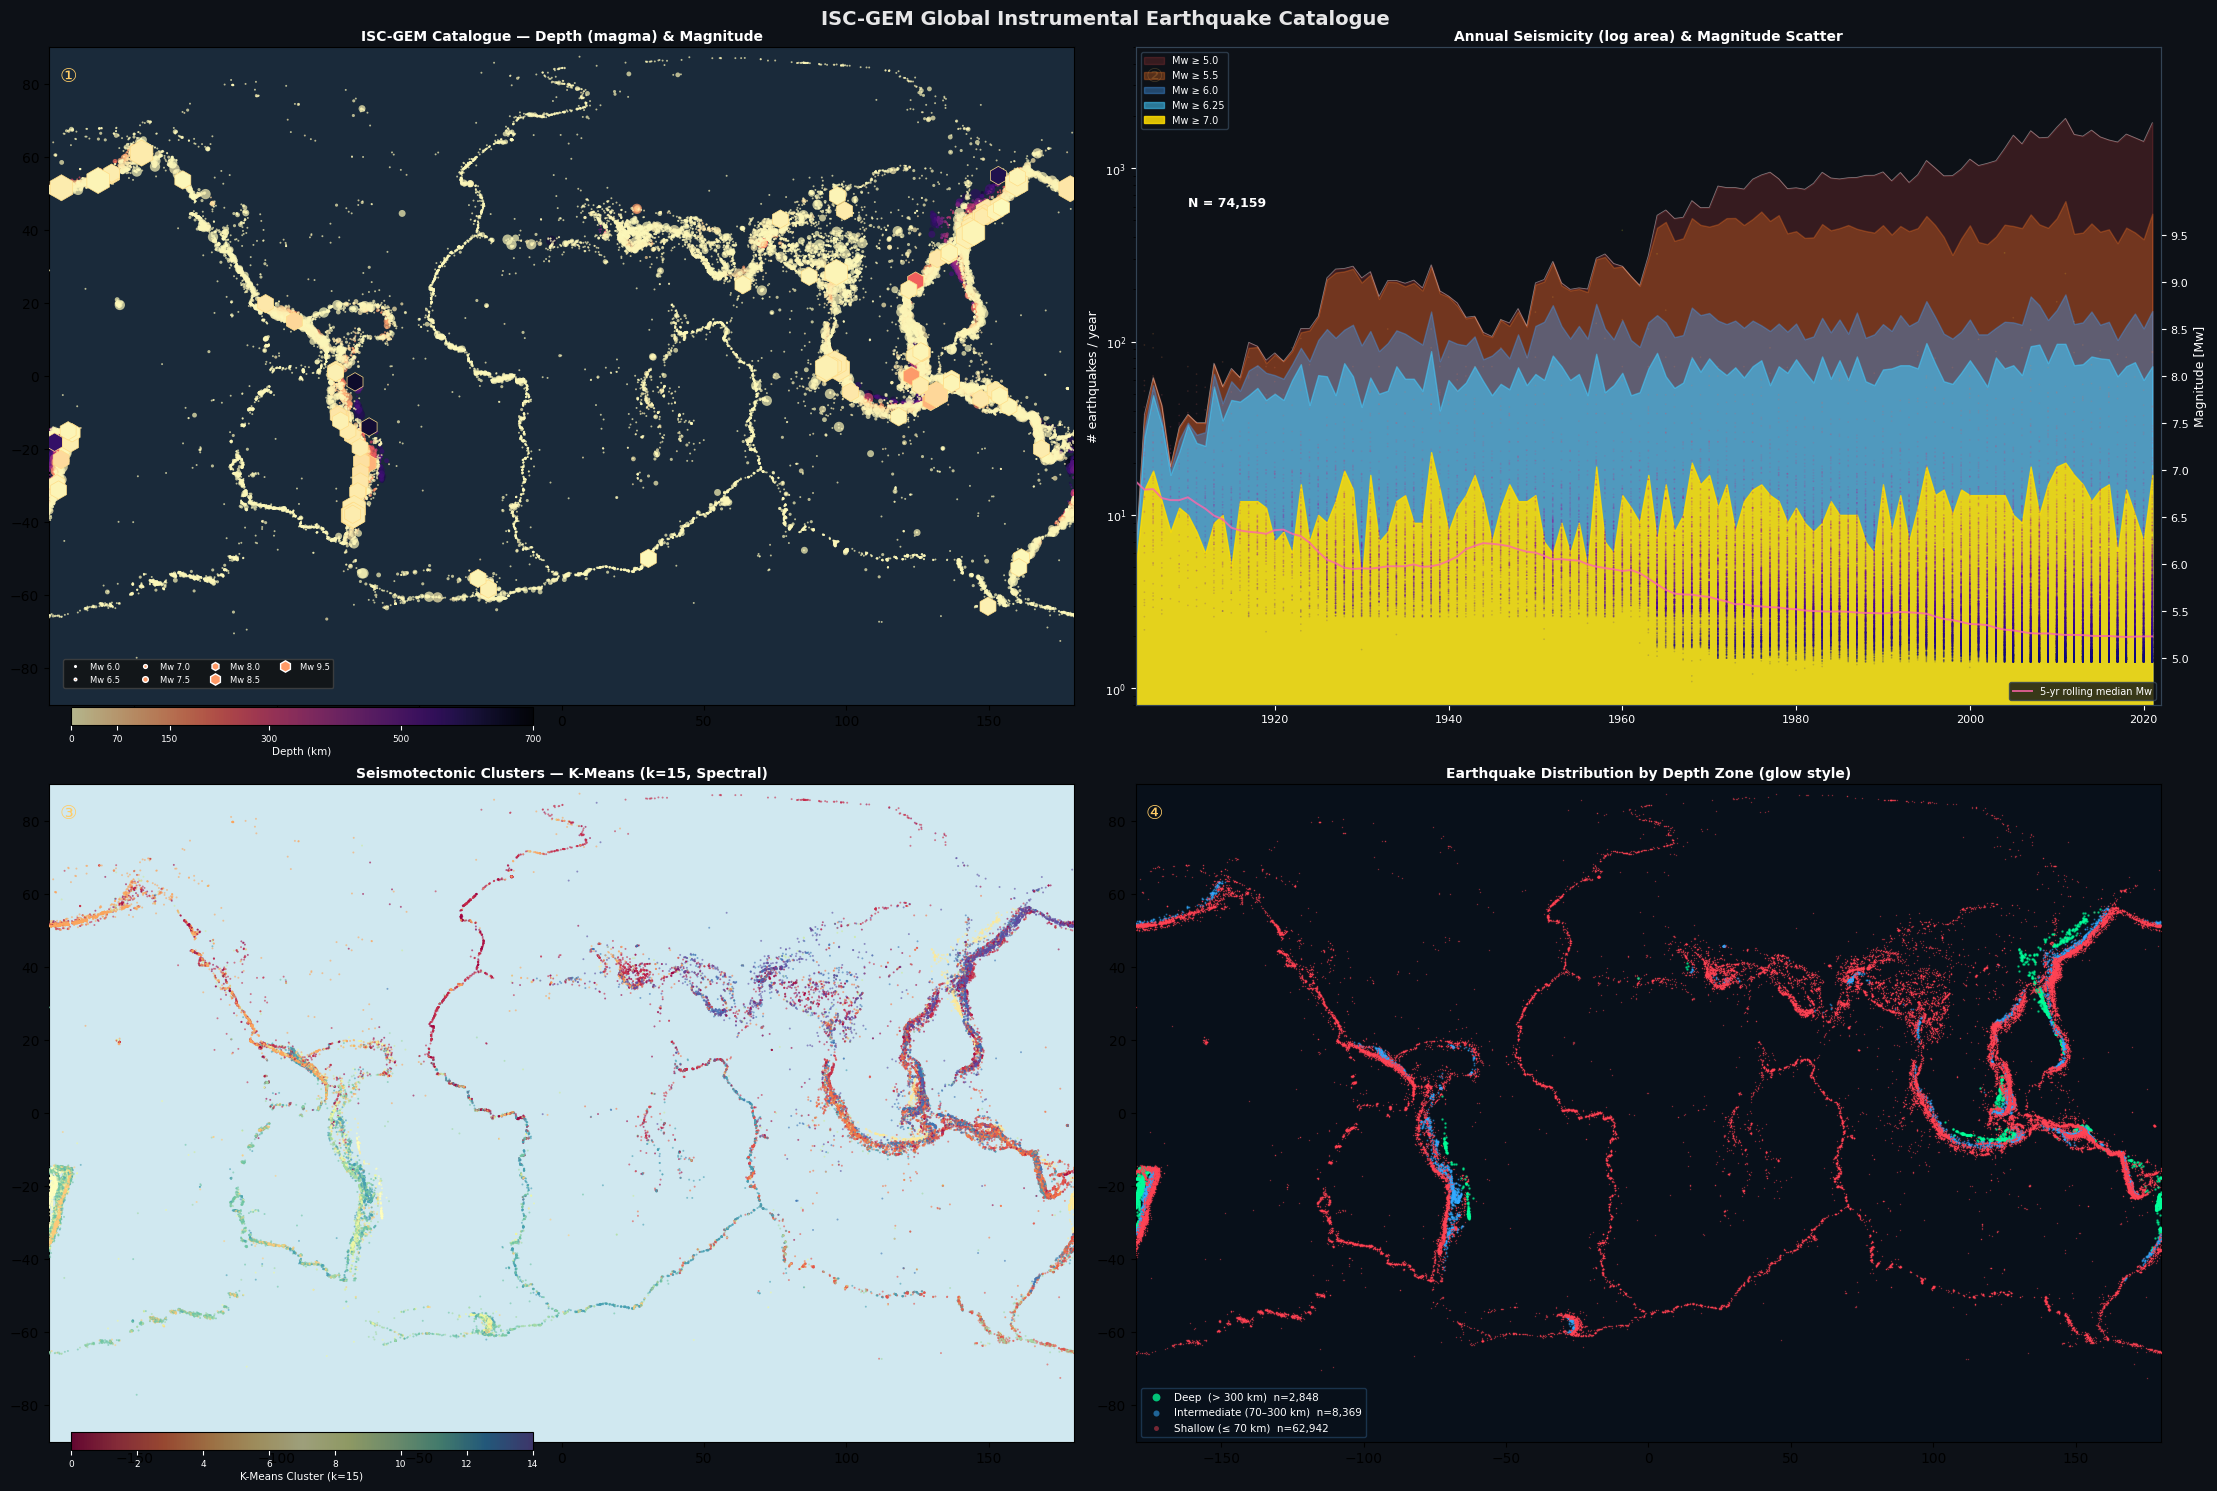

Figure saved as isc_gem_4plots_v2.png


In [ ]:
BG = '#0d1117'   # figure background
years = np.arange(1904, 2022)

norm_d  = mcolors.Normalize(vmin=0,   vmax=700)
norm_mw = mcolors.Normalize(vmin=5.0, vmax=9.6)

fig = plt.figure(figsize=(22, 15), facecolor=BG)
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.12, wspace=0.06,
                        left=0.02, right=0.98, top=0.96, bottom=0.03)

# ─────────────────────────────────────────────────────────────────────────
# PLOT 1  World map: depth colour (magma_r) + Mw size, Robinson projection
# ─────────────────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor('#1a2a3a') # Mimic ocean_color
ax1.set_xlim(-180, 180)
ax1.set_ylim(-90, 90)

df_s = df.sort_values('depth', ascending=False)
sc1  = ax1.scatter(df_s['lon'].values, df_s['lat'].values,
                   c=df_s['depth'].values, cmap='magma_r', norm=norm_d,
                   s=mw_size(df_s['mw'].values), alpha=0.70,
                   linewidths=0, zorder=3)

# Hexagonal markers for Mw ≥ 8  (changed from stars)
big = df_s[df_s['mw'] >= 8.0]
ax1.scatter(big['lon'].values, big['lat'].values,
            c=big['depth'].values, cmap='magma_r', norm=norm_d,
            s=mw_size(big['mw'].values) * 1.6,
            marker='h', edgecolors='#ffdd88', linewidths=0.5,
            zorder=4)

# Colorbar
cax1 = fig.add_axes([0.03, 0.508, 0.21, 0.012])
cb1  = fig.colorbar(sc1, cax=cax1, orientation='horizontal')
cb1.set_ticks([0, 70, 150, 300, 500, 700])
cb1.set_label('Depth (km)', color='white', fontsize=7.5, labelpad=2)
cb1.ax.tick_params(colors='white', labelsize=6.5)
cax1.set_facecolor(BG)

# Magnitude size legend
mw_vals = [6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.5]
leg1 = [Line2D([0],[0],
               marker='h' if mw >= 8 else 'o',
               color='w', markerfacecolor='#ff9966',
               markersize=np.sqrt(mw_size(np.array([mw]))[0]) * 0.55,
               label=f'Mw {mw}', linestyle='None')
        for mw in mw_vals]
ax1.legend(handles=leg1, loc='lower left', fontsize=6, ncol=4,
           facecolor='#111111', labelcolor='white', edgecolor='#444',
           framealpha=0.8, bbox_to_anchor=(0.01, 0.02))
ax1.set_title('ISC-GEM Catalogue — Depth (magma) & Magnitude',
              color='white', fontsize=10, pad=5, fontweight='semibold')
ax1.text(0.01, 0.97, '①', transform=ax1.transAxes,
         color='#ffcc66', fontsize=14, va='top')

# ─────────────────────────────────────────────────────────────────────────
# PLOT 2  Gradient area chart (total counts, log) + median Mw trend
# ─────────────────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor('#0d1117')

b50  = count_per_year(df, 5.0, 5.5,  years)
b55  = count_per_year(df, 5.5, 6.0,  years)
b60  = count_per_year(df, 6.0, 6.25, years)
b625 = count_per_year(df, 6.25, 7.0, years)
b70  = count_per_year(df, 7.0,       years=years)
total = b50 + b55 + b60 + b625 + b70

# Stacked filled areas (semi-transparent, gradient-like effect)
cum5  = b55 + b60 + b625 + b70
cum6  = b60 + b625 + b70
cum625= b625 + b70

ax2.fill_between(years, 0.8, total,   alpha=0.20, color='#dd4444', label='Mw ≥ 5.0')
ax2.fill_between(years, 0.8, cum5,    alpha=0.30, color='#ff7722', label='Mw ≥ 5.5')
ax2.fill_between(years, 0.8, cum6,    alpha=0.40, color='#4499ee', label='Mw ≥ 6.0')
ax2.fill_between(years, 0.8, cum625,  alpha=0.55, color='#44ccff', label='Mw ≥ 6.25')
ax2.fill_between(years, 0.8, b70,     alpha=0.85, color='#ffdd00', label='Mw ≥ 7.0')
ax2.plot(years, total, color='#ffffff', linewidth=0.6, alpha=0.4)

ax2.set_yscale('log')
ax2.set_ylim(0.8, 5000)
ax2.set_xlim(1904, 2022)
ax2.set_ylabel('# earthquakes / year', color='white', fontsize=9)
ax2.tick_params(colors='white', labelsize=8)
for spine in ax2.spines.values():
    spine.set_edgecolor('#334455')

# N annotation
ax2.text(1910, 600, f'N = {len(df):,}', color='white', fontsize=9, fontweight='bold')

ax2.legend(fontsize=7, facecolor='#0d1117', labelcolor='white',
           edgecolor='#334455', loc='upper left')

# Right axis: magnitude scatter + 5-yr rolling median trend line
ax2r = ax2.twinx()
ax2r.set_facecolor('#0d1117')
ax2r.scatter(df['year'], df['mw'], c=df['mw'], cmap='plasma', norm=norm_mw,
             s=1.5, alpha=0.18, linewidths=0)

# Rolling median Mw (5-year window)
med_mw = (df.groupby('year')['mw'].median()
            .reindex(np.arange(1904, 2022))
            .rolling(5, center=True, min_periods=1).mean())
ax2r.plot(med_mw.index, med_mw.values,
          color='#ff66aa', linewidth=1.4, alpha=0.8,
          label='5-yr rolling median Mw')
ax2r.legend(fontsize=7, facecolor='#0d1117', labelcolor='white',
            edgecolor='#334455', loc='lower right')

ax2r.set_ylim(4.5, 11.5)
ax2r.set_ylabel('Magnitude [Mw]', color='white', fontsize=9)
ax2r.tick_params(colors='white', labelsize=8)
ax2r.set_yticks([5, 5.5, 6, 6.5, 7, 7.5, 8, 8.5, 9, 9.5])
for spine in ax2r.spines.values():
    spine.set_edgecolor('#334455')

ax2.set_title('Annual Seismicity (log area) & Magnitude Scatter',
              color='white', fontsize=10, pad=5, fontweight='semibold')
ax2.text(0.01, 0.97, '②', transform=ax2.transAxes,
         color='#ffcc66', fontsize=14, va='top')

# ─────────────────────────────────────────────────────────────────────────
# PLOT 3  K-Means cluster map — Spectral palette, cool ocean
# ─────────────────────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.set_facecolor('#d0e8f0') # Mimic ocean_color
ax3.set_xlim(-180, 180)
ax3.set_ylim(-90, 90)

sc3 = ax3.scatter(df_clean['lon'].values, df_clean['lat'].values,
                  c=df_clean['cluster'].values,
                  cmap='Spectral', vmin=0, vmax=14,
                  s=2.0, alpha=0.60, linewidths=0, zorder=3)

cax3 = fig.add_axes([0.03, 0.025, 0.21, 0.012])
cb3  = fig.colorbar(sc3, cax=cax3, orientation='horizontal')
cb3.set_ticks(range(0, 15, 2))
cb3.set_label('K-Means Cluster (k=15)', color='white', fontsize=7.5, labelpad=2)
cb3.ax.tick_params(colors='white', labelsize=6.5)
cax3.set_facecolor(BG)

ax3.set_title('Seismotectonic Clusters — K-Means (k=15, Spectral)',
              color='white', fontsize=10, pad=5, fontweight='semibold')
ax3.text(0.01, 0.97, '③', transform=ax3.transAxes,
         color='#ffcc66', fontsize=14, va='top')

# ─────────────────────────────────────────────────────────────────────────
# PLOT 4  Depth-zone map — glow-style scatter, dark navy ocean
# ─────────────────────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
ax4.set_facecolor('#08101a') # Mimic ocean_color
ax4.set_xlim(-180, 180)
ax4.set_ylim(-90, 90)

depth_zones = [
    # (subset, color, sizes, alphas, label)  — two scatter calls per zone create glow
    (df[df['depth'] > 300],                      '#00ff99', [6.0, 2.0], [0.15, 0.75], 'Deep  (> 300 km)'),
    (df[(df['depth'] > 70) & (df['depth'] <= 300)], '#33aaff', [4.0, 1.2], [0.10, 0.55], 'Intermediate (70–300 km)'),
    (df[df['depth'] <= 70],                       '#ff4455', [2.5, 0.8], [0.08, 0.45], 'Shallow (≤ 70 km)'),
]

for sub, col, sizes, alphas, lbl in depth_zones:
    # Glow halo pass
    ax4.scatter(sub['lon'].values, sub['lat'].values,
                c=col, s=sizes[0], alpha=alphas[0], linewidths=0,
                zorder=3)
    # Core dot pass
    ax4.scatter(sub['lon'].values, sub['lat'].values,
                c=col, s=sizes[1], alpha=alphas[1], linewidths=0,
                zorder=4,
                label=f'{lbl}  n={len(sub):,}')

# Latitude grid lines (cartopy gridlines removed)
# gl = ax4.gridlines(crs=ccrs.PlateCarree(), draw_labels=False,
#                    linewidth=0.4, color='#1e3a55',
#                    alpha=0.6, linestyle='--')
# gl.ylocator = mticker.FixedLocator([-60, -30, 0, 30, 60])

ax4.legend(fontsize=7.5, facecolor='#08101a', labelcolor='white',
           edgecolor='#1e3a55', loc='lower left',
           markerscale=4, framealpha=0.85)
ax4.set_title('Earthquake Distribution by Depth Zone (glow style)',
              color='white', fontsize=10, pad=5, fontweight='semibold')
ax4.text(0.01, 0.97, '④', transform=ax4.transAxes,
         color='#ffcc66', fontsize=14, va='top')

# ── Overall title ────────────────────────────────────────────────────────
fig.text(0.5, 0.985, 'ISC-GEM Global Instrumental Earthquake Catalogue',
         ha='center', va='top', color='white',
         fontsize=14, fontweight='bold', alpha=0.9)

plt.savefig('isc_gem_4plots_v2.png', dpi=160, bbox_inches='tight',
            facecolor=BG, edgecolor='none')
plt.show()
print("Figure saved as isc_gem_4plots_v2.png")

---
## Part 2: Clustering Analysis (K-Means, DBSCAN, Hierarchical)
---

# ISC-GEM Earthquake Catalogue — Clustering Analysis

**Dataset:** ISC-GEM Global Instrumental Earthquake Catalogue v12.1  
**Features used:** Latitude, Longitude, Depth, Mw, Strike, Dip, Rake  
**Algorithms:** K-Means, DBSCAN, Hierarchical (Ward)  
**Working dataset:** ~50,917 events with complete focal mechanism data

## 1. Feature Selection & Preprocessing

In [ ]:
FEATURES = ['lat', 'lon', 'depth', 'mw', 'str1', 'dip1', 'rake1']

df_clean = df_main[FEATURES].dropna().reset_index(drop=True)
print(f"Events with complete focal mechanism data: {len(df_clean):,}")
print(f"\nFeature statistics:")
print(df_clean.describe().round(2))

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df_clean.values)

df_clean['fault_type'] = df_clean['rake1'].apply(fault_type)
print("\nFault-type distribution:")
print(df_clean['fault_type'].value_counts())

Events with complete focal mechanism data: 50,917

Feature statistics:
            lat       lon     depth        mw      str1      dip1     rake1
count  50917.00  50917.00  50917.00  50917.00  50917.00  50917.00  50917.00
mean       0.06     30.38     65.50      5.48     98.00     59.35     29.63
std       30.43    124.88    117.01      0.48     71.25     20.48     98.09
min      -77.08   -180.00      0.00      4.75      0.00      0.00   -180.00
25%      -20.46    -82.63     15.00      5.14     34.00     45.00    -60.00
50%       -4.00     87.95     24.70      5.35     88.00     62.00     70.00
75%       23.07    142.19     51.10      5.68    151.00     76.00    101.00
max       87.35    180.00    693.10      9.55    359.00     90.00    180.00

Fault-type distribution:
fault_type
Thrust/Reverse    18070
Strike-slip       14890
Normal             9181
Oblique            8776
Name: count, dtype: int64


## 2. K-Means — Elbow + Silhouette

In [ ]:
inertias, sil_scores = [], []
ks = range(3, 16)

for k in ks:
    km_    = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km_.fit_predict(X_scaled)
    inertias.append(km_.inertia_)
    sil = silhouette_score(X_scaled, labels, sample_size=5000, random_state=42)
    sil_scores.append(sil)
    print(f"  k={k:2d} | inertia={km_.inertia_:,.0f} | silhouette={sil:.4f}")

best_k = list(ks)[sil_scores.index(max(sil_scores))]
print(f"\nBest k by silhouette: {best_k}")

  k= 3 | inertia=268,923 | silhouette=0.1767
  k= 4 | inertia=241,920 | silhouette=0.1733
  k= 5 | inertia=220,188 | silhouette=0.1761
  k= 6 | inertia=202,941 | silhouette=0.1628
  k= 7 | inertia=189,114 | silhouette=0.1676
  k= 8 | inertia=178,186 | silhouette=0.1728
  k= 9 | inertia=169,510 | silhouette=0.1738
  k=10 | inertia=162,380 | silhouette=0.1734
  k=11 | inertia=156,570 | silhouette=0.1741
  k=12 | inertia=150,662 | silhouette=0.1777
  k=13 | inertia=146,258 | silhouette=0.1774
  k=14 | inertia=140,642 | silhouette=0.1820
  k=15 | inertia=136,416 | silhouette=0.1862

Best k by silhouette: 15


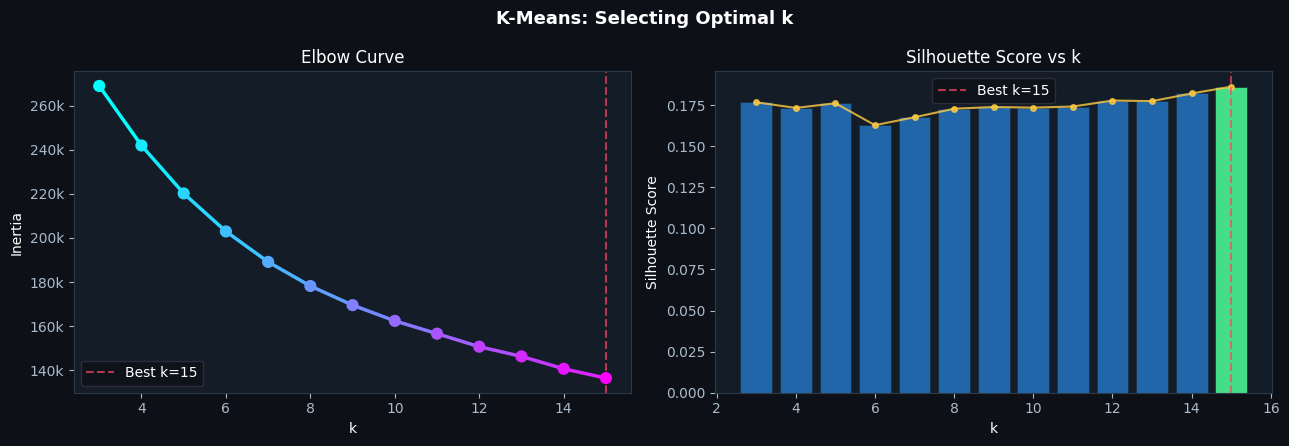

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5),
                          facecolor='#0d1117')
fig.suptitle('K-Means: Selecting Optimal k', fontsize=13, fontweight='bold',
             color='white')

for ax in axes:
    ax.set_facecolor('#131c27')
    ax.tick_params(colors='#aabbcc')
    for spine in ax.spines.values():
        spine.set_edgecolor('#2a3a4a')

# Elbow — gradient line using a colormap
ks_list = list(ks)
for i in range(len(ks_list) - 1):
    c = plt.cm.cool(i / len(ks_list))
    axes[0].plot(ks_list[i:i+2], inertias[i:i+2], '-', color=c, linewidth=2.5)
axes[0].scatter(ks_list, inertias, c=range(len(ks_list)), cmap='cool', s=60, zorder=5)
axes[0].set_xlabel('k', color='white'); axes[0].set_ylabel('Inertia', color='white')
axes[0].set_title('Elbow Curve', color='white')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x/1000:.0f}k'))
axes[0].axvline(best_k, color='#ff4466', ls='--', alpha=0.7, label=f'Best k={best_k}')
axes[0].legend(facecolor='#0d1117', labelcolor='white', edgecolor='#334')

# Silhouette — bar chart
bar_cols = ['#44dd88' if k == best_k else '#2266aa' for k in ks_list]
axes[1].bar(ks_list, sil_scores, color=bar_cols, edgecolor='#1a2a3a', linewidth=0.5)
axes[1].plot(ks_list, sil_scores, 'o-', color='#ffcc44', linewidth=1.5,
             markersize=4, alpha=0.8)
axes[1].set_xlabel('k', color='white'); axes[1].set_ylabel('Silhouette Score', color='white')
axes[1].set_title('Silhouette Score vs k', color='white')
axes[1].axvline(best_k, color='#ff4466', ls='--', alpha=0.7, label=f'Best k={best_k}')
axes[1].legend(facecolor='#0d1117', labelcolor='white', edgecolor='#334')

plt.tight_layout()
plt.show()

## 3. Fit Best K-Means Model

In [ ]:
km_best   = KMeans(n_clusters=best_k, random_state=42, n_init=10)
km_labels = km_best.fit_predict(X_scaled)
df_clean['km_cluster'] = km_labels

sil = silhouette_score(X_scaled, km_labels, sample_size=5000, random_state=42)
db  = davies_bouldin_score(X_scaled, km_labels)
ch  = calinski_harabasz_score(X_scaled, km_labels)

print(f"K-Means (k={best_k}) Metrics")
print(f"  Silhouette Score:        {sil:.4f}")
print(f"  Davies-Bouldin Score:    {db:.4f}  (lower = better)")
print(f"  Calinski-Harabasz Score: {ch:.1f}  (higher = better)")
print(f"\nCluster sizes:")
print(pd.Series(km_labels).value_counts().sort_index())

K-Means (k=15) Metrics
  Silhouette Score:        0.1862
  Davies-Bouldin Score:    1.4739  (lower = better)
  Calinski-Harabasz Score: 5863.7  (higher = better)

Cluster sizes:
0     2873
1     3604
2     4145
3     5815
4     3469
5     3258
6     1137
7     1392
8     2097
9     3047
10    2551
11    3662
12    3693
13    4419
14    5755
Name: count, dtype: int64


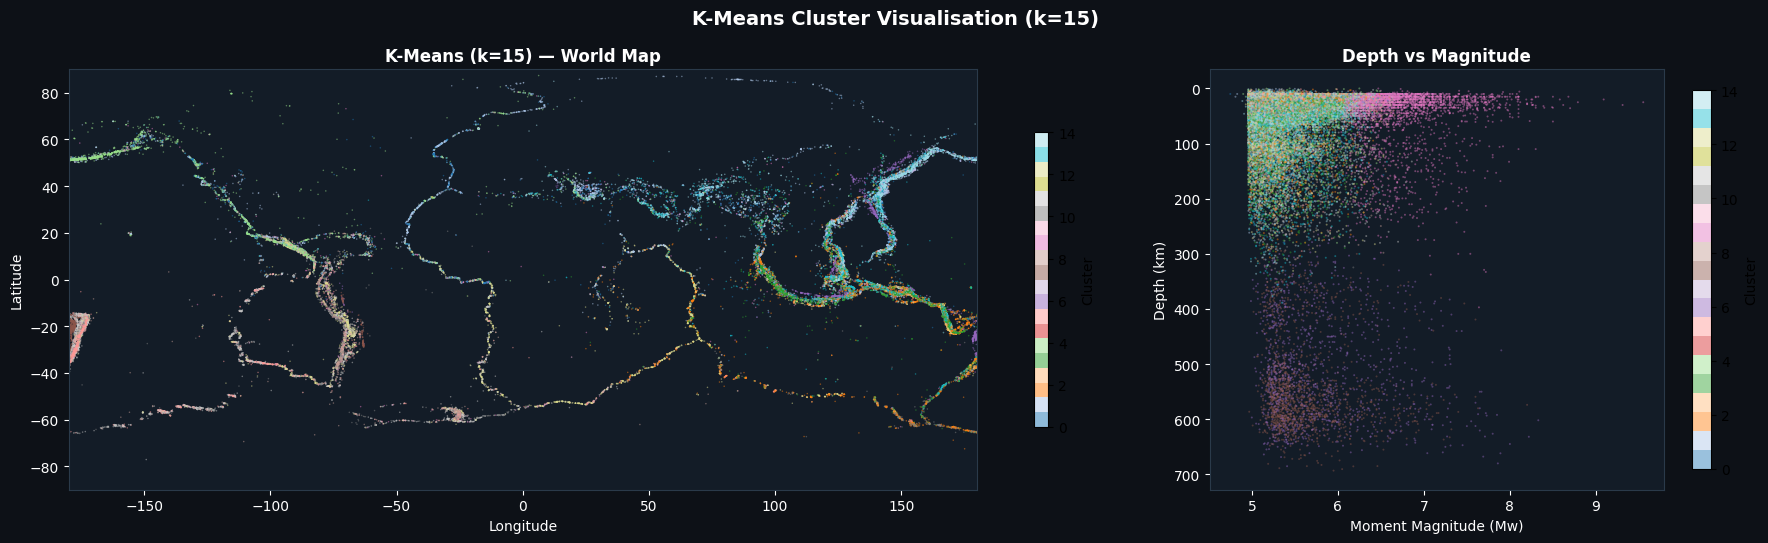

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5.5),
                          gridspec_kw={'width_ratios': [2, 1]},
                          facecolor='#0d1117')

# Left: world scatter
ax = axes[0]
ax.set_facecolor('#131c27')
sc = ax.scatter(df_clean['lon'], df_clean['lat'],
                c=km_labels, cmap='tab20',
                s=1.2, alpha=0.5, linewidths=0)
plt.colorbar(sc, ax=ax, label='Cluster', shrink=0.7)
ax.set_xlim(-180, 180); ax.set_ylim(-90, 90)
ax.set_xlabel('Longitude', color='white'); ax.set_ylabel('Latitude', color='white')
ax.set_title(f'K-Means (k={best_k}) — World Map', fontsize=12, fontweight='bold', color='white')
ax.tick_params(colors='white')
for spine in ax.spines.values(): spine.set_edgecolor('#2a3a4a')

# Right: depth vs magnitude
ax2 = axes[1]
ax2.set_facecolor('#131c27')
sc2 = ax2.scatter(df_clean['mw'], df_clean['depth'],
                  c=km_labels, cmap='tab20',
                  s=2.0, alpha=0.45, linewidths=0)
plt.colorbar(sc2, ax=ax2, label='Cluster', shrink=0.9)
ax2.invert_yaxis()
ax2.set_xlabel('Moment Magnitude (Mw)', color='white')
ax2.set_ylabel('Depth (km)', color='white')
ax2.set_title('Depth vs Magnitude', fontsize=12, fontweight='bold', color='white')
ax2.tick_params(colors='white')
for spine in ax2.spines.values(): spine.set_edgecolor('#2a3a4a')

fig.suptitle(f'K-Means Cluster Visualisation (k={best_k})',
             fontsize=14, fontweight='bold', color='white')
plt.tight_layout()
plt.show()

### Cluster Profiles

In [ ]:
summary = df_clean.groupby('km_cluster').agg(
    count=('lat', 'count'),
    lat_mean=('lat', 'mean'),
    lon_mean=('lon', 'mean'),
    depth_mean=('depth', 'mean'),
    mw_mean=('mw', 'mean'),
    mw_max=('mw', 'max'),
    dominant_fault=('fault_type', lambda x: x.value_counts().index[0])
).round(2)

print(summary.to_string())

            count  lat_mean  lon_mean  depth_mean  mw_mean  mw_max  dominant_fault
km_cluster                                                                        
0            2873     22.84     43.32       30.75     5.45    7.10     Strike-slip
1            3604     30.22     47.17       28.51     5.32    6.49          Normal
2            4145    -12.71    132.61       38.51     5.37    6.60     Strike-slip
3            5815     -5.48    137.25       50.54     5.38    6.30  Thrust/Reverse
4            3469     35.10   -112.00       32.34     5.41    6.61  Thrust/Reverse
5            3258    -28.03   -145.04       26.05     5.42    6.66  Thrust/Reverse
6            1137      6.34    141.09      507.13     5.81    8.33          Normal
7            1392    -20.47   -168.17      540.18     5.62    8.20          Normal
8            2097    -28.07    -88.92       43.25     5.45    6.85  Thrust/Reverse
9            3047      4.71     74.64       45.47     6.71    9.55  Thrust/Reverse
10  

## 4. DBSCAN Clustering

`DBSCAN` is imported from `sklearn.cluster` — no additional install required.

In [ ]:
print(f"{'eps':>6} | {'min_s':>6} | {'clusters':>9} | {'noise %':>8} | {'silhouette':>11}")
print("-" * 55)

results_db = []

for eps in [0.5, 0.8, 1.0, 1.2]:
    db_     = DBSCAN(eps=eps, min_samples=10, n_jobs=-1)
    labels  = db_.fit_predict(X_scaled)
    n_clust = len(set(labels)) - (1 if -1 in labels else 0)
    noise   = 100 * (labels == -1).sum() / len(labels)
    mask    = labels != -1
    sil     = (silhouette_score(X_scaled[mask], labels[mask],
                                sample_size=5000, random_state=42)
               if n_clust > 1 else float('nan'))
    results_db.append((eps, 10, n_clust, noise, sil, labels))
    print(f"{eps:>6.1f} | {10:>6} | {n_clust:>9} | {noise:>7.1f}% | {sil:>11.4f}")

   eps |  min_s |  clusters |  noise % |  silhouette
-------------------------------------------------------
   0.5 |     10 |       112 |    35.8% |     -0.1794
   0.8 |     10 |        19 |     7.6% |     -0.0666
   1.0 |     10 |         9 |     2.9% |      0.0664
   1.2 |     10 |         4 |     1.1% |      0.3463


DBSCAN: 19 clusters, 3868 noise points (7.6%)


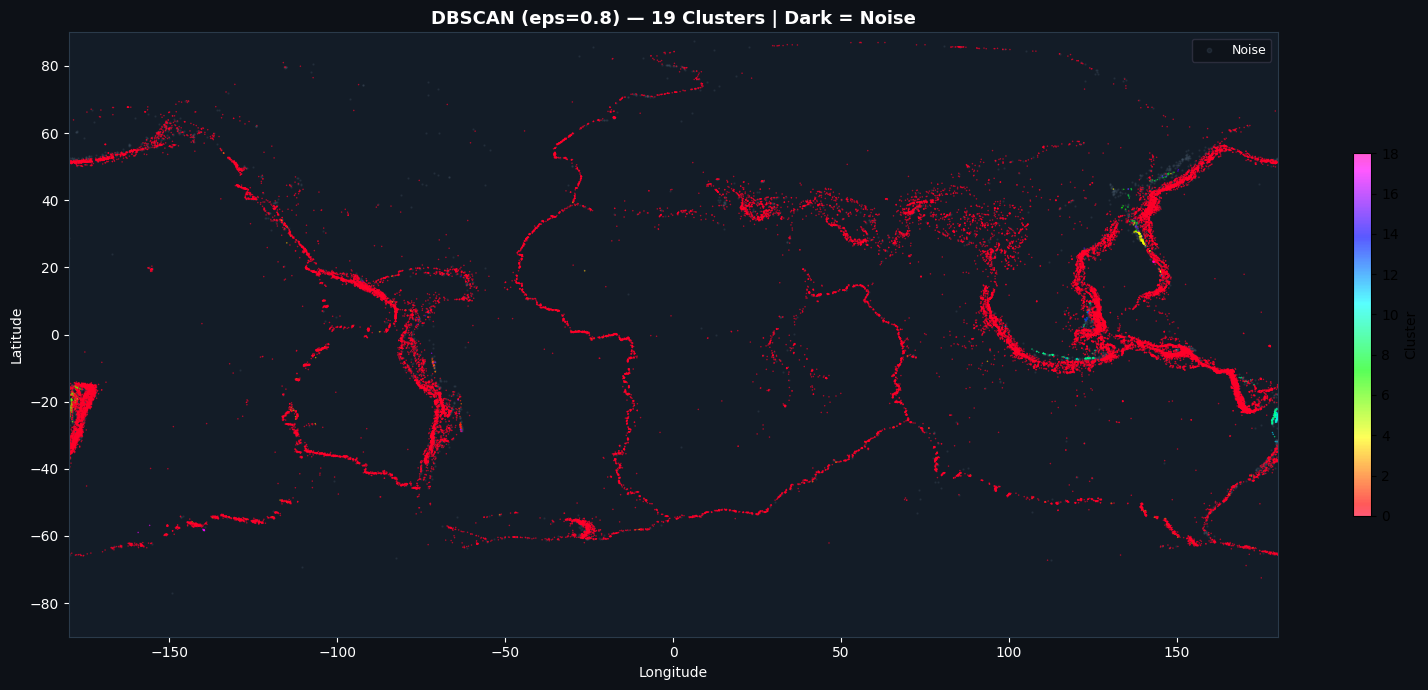

In [ ]:
db_best   = DBSCAN(eps=0.8, min_samples=10, n_jobs=-1)
db_labels = db_best.fit_predict(X_scaled)
df_clean['db_cluster'] = db_labels

n_db    = len(set(db_labels)) - (1 if -1 in db_labels else 0)
noise_n = (db_labels == -1).sum()
print(f"DBSCAN: {n_db} clusters, {noise_n} noise points "
      f"({100*noise_n/len(db_labels):.1f}%)")

fig, ax = plt.subplots(figsize=(16, 7), facecolor='#0d1117')
ax.set_facecolor('#131c27')

noise_mask = db_labels == -1
ax.scatter(df_clean.loc[noise_mask, 'lon'],
           df_clean.loc[noise_mask, 'lat'],
           c='#445566', s=0.4, alpha=0.25, label='Noise')

core_mask = ~noise_mask
sc = ax.scatter(df_clean.loc[core_mask, 'lon'],
                df_clean.loc[core_mask, 'lat'],
                c=db_labels[core_mask], cmap='gist_rainbow',
                s=1.2, alpha=0.65, linewidths=0)
plt.colorbar(sc, ax=ax, label='Cluster', shrink=0.6)

ax.set_xlim(-180, 180); ax.set_ylim(-90, 90)
ax.set_xlabel('Longitude', color='white')
ax.set_ylabel('Latitude', color='white')
ax.set_title(f'DBSCAN (eps=0.8) — {n_db} Clusters | Dark = Noise',
             fontsize=13, fontweight='bold', color='white')
ax.tick_params(colors='white')
for spine in ax.spines.values(): spine.set_edgecolor('#2a3a4a')
ax.legend(markerscale=5, fontsize=9, facecolor='#0d1117',
          labelcolor='white', edgecolor='#334')
plt.tight_layout()
plt.show()

## 5. Hierarchical Clustering (Ward Linkage)

`AgglomerativeClustering` is imported from `sklearn.cluster` — no additional install required.

> Run on a 10,000-event sample for computational efficiency.

In [ ]:
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), 10000, replace=False)
X_sample   = X_scaled[sample_idx]
df_sample  = df_clean.iloc[sample_idx].copy().reset_index(drop=True)

print(f"{'k':>4} | {'silhouette':>11}")
print("-" * 20)
hc_sil_scores = {}
for k in [5, 8, 10, 12, 15]:
    hc_    = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = hc_.fit_predict(X_sample)
    sil    = silhouette_score(X_sample, labels, sample_size=3000, random_state=42)
    hc_sil_scores[k] = sil
    print(f"{k:>4} | {sil:>11.4f}")

   k |  silhouette
--------------------
   5 |      0.1063
   8 |      0.1281
  10 |      0.1205
  12 |      0.1181
  15 |      0.1241


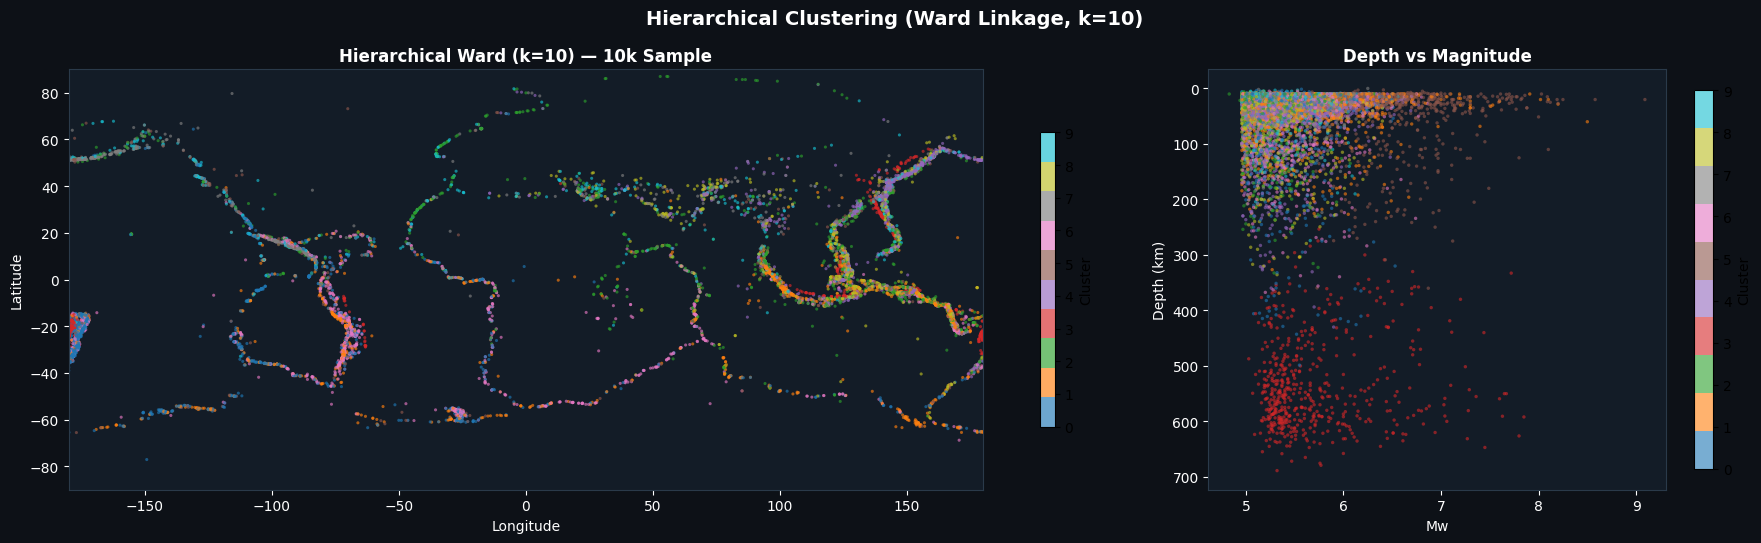

In [ ]:
hc_best   = AgglomerativeClustering(n_clusters=10, linkage='ward')
hc_labels = hc_best.fit_predict(X_sample)
df_sample['hc_cluster'] = hc_labels

fig, axes = plt.subplots(1, 2, figsize=(18, 5.5),
                          gridspec_kw={'width_ratios': [2, 1]},
                          facecolor='#0d1117')

ax = axes[0]
ax.set_facecolor('#131c27')
sc = ax.scatter(df_sample['lon'], df_sample['lat'],
                c=hc_labels, cmap='tab10',
                s=5, alpha=0.65, linewidths=0)
plt.colorbar(sc, ax=ax, label='Cluster', shrink=0.7)
ax.set_xlim(-180, 180); ax.set_ylim(-90, 90)
ax.set_xlabel('Longitude', color='white')
ax.set_ylabel('Latitude', color='white')
ax.set_title('Hierarchical Ward (k=10) — 10k Sample', fontsize=12,
             fontweight='bold', color='white')
ax.tick_params(colors='white')
for spine in ax.spines.values(): spine.set_edgecolor('#2a3a4a')

# Depth vs magnitude for HC
ax2 = axes[1]
ax2.set_facecolor('#131c27')
sc2 = ax2.scatter(df_sample['mw'], df_sample['depth'],
                  c=hc_labels, cmap='tab10',
                  s=6, alpha=0.6, linewidths=0)
plt.colorbar(sc2, ax=ax2, label='Cluster', shrink=0.9)
ax2.invert_yaxis()
ax2.set_xlabel('Mw', color='white'); ax2.set_ylabel('Depth (km)', color='white')
ax2.set_title('Depth vs Magnitude', fontsize=12, fontweight='bold', color='white')
ax2.tick_params(colors='white')
for spine in ax2.spines.values(): spine.set_edgecolor('#2a3a4a')

fig.suptitle('Hierarchical Clustering (Ward Linkage, k=10)',
             fontsize=14, fontweight='bold', color='white')
plt.tight_layout()
plt.show()

## 6. PCA 2D Projection — All Three Algorithms

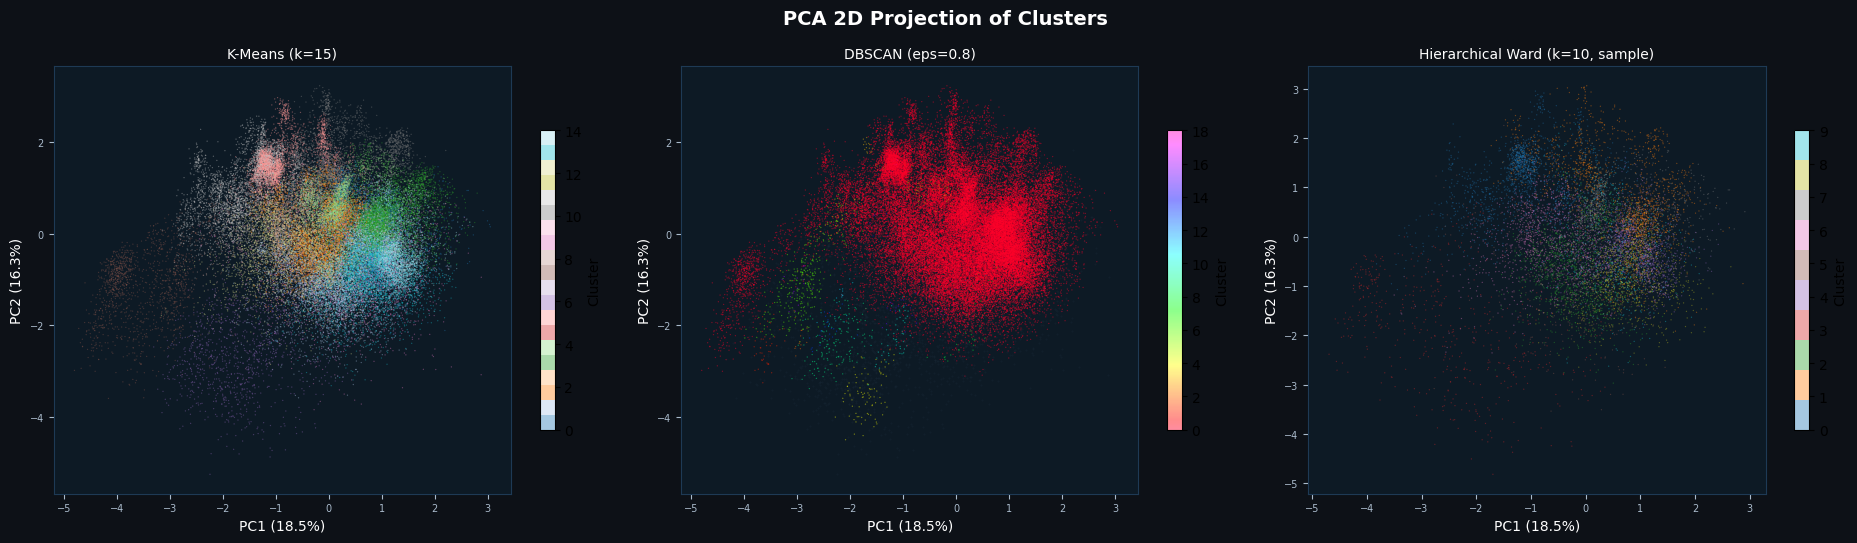

In [ ]:
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
var1, var2 = pca.explained_variance_ratio_ * 100

fig, axes = plt.subplots(1, 3, figsize=(19, 5.5), facecolor='#0d1117')
fig.suptitle('PCA 2D Projection of Clusters', fontsize=14,
             fontweight='bold', color='white')

titles = [f'K-Means (k={best_k})', 'DBSCAN (eps=0.8)', 'Hierarchical Ward (k=10, sample)']
cmaps  = ['tab20', 'gist_rainbow', 'tab10']

noise_mask = db_labels == -1
X_pca_sample = X_pca[sample_idx]

label_sets = [km_labels, db_labels, hc_labels]
pca_sets   = [X_pca, X_pca, X_pca_sample]

for ax, title, cmap, lbl, pca_xy in zip(axes, titles, cmaps, label_sets, pca_sets):
    ax.set_facecolor('#0d1a25')
    if 'DBSCAN' in title:
        noise_m = lbl == -1
        ax.scatter(pca_xy[noise_m, 0], pca_xy[noise_m, 1],
                   c='#223344', s=0.3, alpha=0.2)
        core_m = ~noise_m
        sc = ax.scatter(pca_xy[core_m, 0], pca_xy[core_m, 1],
                        c=lbl[core_m], cmap=cmap, s=0.9, alpha=0.45, linewidths=0)
    else:
        sc = ax.scatter(pca_xy[:, 0], pca_xy[:, 1],
                        c=lbl, cmap=cmap, s=0.9, alpha=0.4, linewidths=0)
    plt.colorbar(sc, ax=ax, shrink=0.7, label='Cluster')
    ax.set_title(title, color='white', fontsize=10)
    ax.set_xlabel(f'PC1 ({var1:.1f}%)', color='white')
    ax.set_ylabel(f'PC2 ({var2:.1f}%)', color='white')
    ax.tick_params(colors='#aabbcc', labelsize=7)
    for spine in ax.spines.values(): spine.set_edgecolor('#1e3a55')

plt.tight_layout()
plt.show()

## 7. Algorithm Comparison Summary

Algorithm                     Clusters   Silhouette  Notes
------------------------------------------------------------------------------
K-Means                             15       0.1862  Best k from silhouette sweep 3-15
DBSCAN (eps=0.8)                    19      -0.0666  Noise points excluded from score
Hierarchical Ward (k=10)            10       0.1205  Run on 10k sample


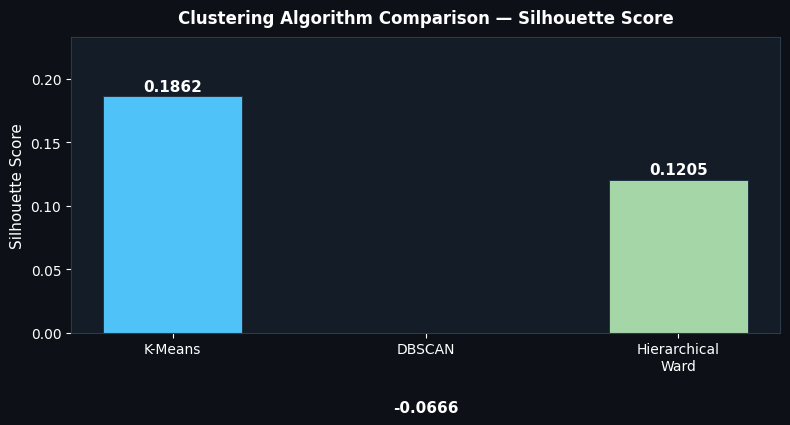

In [ ]:
km_sil  = silhouette_score(X_scaled, km_labels, sample_size=5000, random_state=42)
km_db_s = davies_bouldin_score(X_scaled, km_labels)
km_ch   = calinski_harabasz_score(X_scaled, km_labels)

db_mask = db_labels != -1
db_sil  = silhouette_score(X_scaled[db_mask], db_labels[db_mask],
                           sample_size=5000, random_state=42)

hc_sil  = silhouette_score(X_sample, hc_labels, sample_size=3000, random_state=42)

print(f"{'Algorithm':<28} {'Clusters':>9} {'Silhouette':>12}  Notes")
print("-" * 78)
print(f"{'K-Means':<28} {best_k:>9} {km_sil:>12.4f}  Best k from silhouette sweep 3-15")
print(f"{'DBSCAN (eps=0.8)':<28} {len(set(db_labels))-(1 if -1 in db_labels else 0):>9} "
      f"{db_sil:>12.4f}  Noise points excluded from score")
print(f"{'Hierarchical Ward (k=10)':<28} {10:>9} {hc_sil:>12.4f}  Run on 10k sample")

# ── Comparison bar chart ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4.5), facecolor='#0d1117')
ax.set_facecolor('#131c27')

algos  = ['K-Means', 'DBSCAN', 'Hierarchical\nWard']
scores = [km_sil, db_sil, hc_sil]
colors = ['#4fc3f7', '#ff8a65', '#a5d6a7']

bars = ax.bar(algos, scores, color=colors,
              edgecolor='#223344', linewidth=0.7, width=0.55)

for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.002,
            f'{score:.4f}', ha='center', va='bottom',
            fontweight='bold', color='white', fontsize=11)

ax.set_ylabel('Silhouette Score', color='white', fontsize=11)
ax.set_ylim(0, max(scores) * 1.25)
ax.set_title('Clustering Algorithm Comparison — Silhouette Score',
             fontsize=12, fontweight='bold', color='white', pad=10)
ax.tick_params(colors='white', labelsize=10)
for spine in ax.spines.values(): spine.set_edgecolor('#2a3a4a')
ax.set_facecolor('#131c27')

plt.tight_layout()
plt.show()

## 8. Export Results

In [ ]:
output = df_clean[['lat','lon','depth','mw',
                   'str1','dip1','rake1',
                   'fault_type','km_cluster','db_cluster']].copy()
output.to_csv('isc_gem_clustered_v2.csv', index=False)
print(f"Saved {len(output):,} rows to isc_gem_clustered_v2.csv")
print(output.head())

Saved 50,917 rows to isc_gem_clustered_v2.csv
      lat      lon  depth    mw   str1  dip1  rake1      fault_type  \
0  49.709   98.483   15.0  7.95   92.2  85.5    1.2     Strike-slip   
1  49.292   96.843   15.0  8.33  238.0  64.0   37.0         Oblique   
2  34.175  138.025  300.0  7.40  208.0  80.0   85.0  Thrust/Reverse   
3  51.853  178.180  110.0  8.30  196.0  80.0  -56.0         Oblique   
4  51.086  150.453  550.0  7.65   25.0  42.0 -116.0          Normal   

   km_cluster  db_cluster  
0           9          -1  
1           9          -1  
2           9          -1  
3           9          -1  
4           6          -1  
